In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, LongType
)

spark = SparkSession.builder \
    .master("spark://group13-master:7077") \
    .appName("test") \
    .config("spark.dynamicAllocation.enabled", "true") \
    .config("spark.shuffle.service.enabled", "false") \
    .config("spark.dynamicAllocation.shuffleTracking.enabled", "true") \
    .getOrCreate()

reddit_schema = StructType([
    StructField("author", StringType(), True),
    StructField("body", StringType(), True),
    StructField("normalizedBody", StringType(), True),
    StructField("content", StringType(), True),
    StructField("content_len", LongType(), True),
    StructField("summary", StringType(), True),
    StructField("summary_len", LongType(), True),
    StructField("id", StringType(), True),
    StructField("subreddit", StringType(), True),
    StructField("subreddit_id", StringType(), True),
    StructField("title", StringType(), True)
])

path = "hdfs://group13-master:9000/project/reddit/raw"
df = spark.read.schema(reddit_schema).json(path)
df.show(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 14:48:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/09 14:48:21 WARN StandaloneSchedulerBackend: Dynamic allocation enabled without spark.executor.cores explicitly set, you may get more executors allocated than expected. It's recommended to set spark.executor.cores explicitly. Please check SPARK-30299 for more details.
                                                                                

+----------------+--------------------+--------------------+--------------------+-----------+--------------------+-----------+-------+-----------+------------+--------+
|          author|                body|      normalizedBody|             content|content_len|             summary|summary_len|     id|  subreddit|subreddit_id|   title|
+----------------+--------------------+--------------------+--------------------+-----------+--------------------+-----------+-------+-----------+------------+--------+
|raysofdarkmatter|I think it should...|I think it should...|I think it should...|        178|Shifting seasonal...|          8|c69al3r|       math|    t5_2qh0n|    NULL|
|         Stork13|Art is about the ...|Art is about the ...|Art is about the ...|        148|Personal opinions...|          4|c6a9nxd|      funny|    t5_2qh33|    NULL|
|   Cloud_dreamer|Ask me what I thi...|Ask me what I thi...|Ask me what I thi...|         76|insults and slack...|         73|c6acx4l|Borderlands|    t5_2r

In [2]:
from pyspark.sql.functions import col



# Keeep neccesary columns
clean_df = df.select("author", "subreddit") \
    .filter(col("author").isNotNull()) \
    .filter(col("subreddit").isNotNull()) \
    .filter(col("author") != "[deleted]")

clean_df.show(5, truncate=False)

[Stage 1:>                                                          (0 + 1) / 1]

+----------------+-----------+
|author          |subreddit  |
+----------------+-----------+
|raysofdarkmatter|math       |
|Stork13         |funny      |
|Cloud_dreamer   |Borderlands|
|NightlyReaper   |gamingpc   |
|NuffZetPand0ra  |Diablo     |
+----------------+-----------+
only showing top 5 rows



In [3]:
target_subreddit = "math"
print("Target subreddit:", target_subreddit)

Target subreddit: math


In [4]:
#Active users
from pyspark.sql.functions import lower, count, desc

users = clean_df.filter(col("subreddit") == target_subreddit) \
                .select("author") \
                .distinct()

print("Users in subreddit:", users.count())

user_posts = clean_df.join(users, "author")

print("Total posts by these users:", user_posts.count())

other_posts = user_posts.filter(col("subreddit") != target_subreddit)

print("Posts in other subreddits:", other_posts.count())

Users in subreddit: 962


Total posts by these users: 8146


[Stage 25:>                                                         (0 + 1) / 1]

Posts in other subreddits: 6898


In [5]:
num_partitions = df.rdd.getNumPartitions()
print(num_partitions)

59


In [6]:


clean_df.cache()
clean_df.count()

2000000

In [8]:
top_subreddits = clean_df.groupBy("subreddit") \
                         .count() \
                         .orderBy("count", ascending=False)

top_subreddits.show(20)

[Stage 32:======================================>                   (2 + 1) / 3]

+-----------------+------+
|        subreddit| count|
+-----------------+------+
|        AskReddit|470583|
|  leagueoflegends| 49021|
|    AdviceAnimals| 37231|
|            funny| 35197|
|             pics| 32077|
|           gaming| 31574|
|         politics| 30875|
|          atheism| 27274|
|              WTF| 22966|
|    todayilearned| 22593|
|explainlikeimfive| 22535|
|        worldnews| 20705|
|           videos| 18805|
|             IAmA| 18762|
|            trees| 15806|
|            DotA2| 12788|
|       technology| 12233|
|    relationships| 12075|
|          Fitness| 11070|
|             news| 10617|
+-----------------+------+
only showing top 20 rows



In [10]:
from pyspark.sql.functions import countDistinct
related_subreddits = other_posts.groupBy("subreddit") \
                                .agg(countDistinct("author").alias("unique_users")) \
                                .orderBy("unique_users", ascending=False)

related_subreddits.show(20)

[Stage 38:===================>                                      (1 + 2) / 3]

+-----------------+------------+
|        subreddit|unique_users|
+-----------------+------------+
|        AskReddit|         292|
|         politics|          89|
|          atheism|          82|
|            funny|          81|
|       askscience|          80|
|             pics|          75|
|          science|          68|
|explainlikeimfive|          67|
|    todayilearned|          63|
|           gaming|          62|
|      programming|          61|
|        worldnews|          59|
|       reddit.com|          53|
|              WTF|          50|
|       technology|          49|
|             IAmA|          49|
|    AdviceAnimals|          40|
|           videos|          38|
|          Physics|          37|
|     changemyview|          27|
+-----------------+------------+
only showing top 20 rows



In [11]:
top10 = related_subreddits.limit(10)
top10.show(truncate=False)

+-----------------+------------+
|subreddit        |unique_users|
+-----------------+------------+
|AskReddit        |292         |
|politics         |89          |
|atheism          |82          |
|funny            |81          |
|askscience       |80          |
|pics             |75          |
|science          |68          |
|explainlikeimfive|67          |
|todayilearned    |63          |
|gaming           |62          |
+-----------------+------------+



In [12]:
top10_pd = top10.toPandas()
top10_pd

,subreddit,unique_users
0,AskReddit,292
1,politics,89
2,atheism,82
3,funny,81
4,askscience,80
5,pics,75
6,science,68
7,explainlikeimfive,67
8,todayilearned,63
9,gaming,62


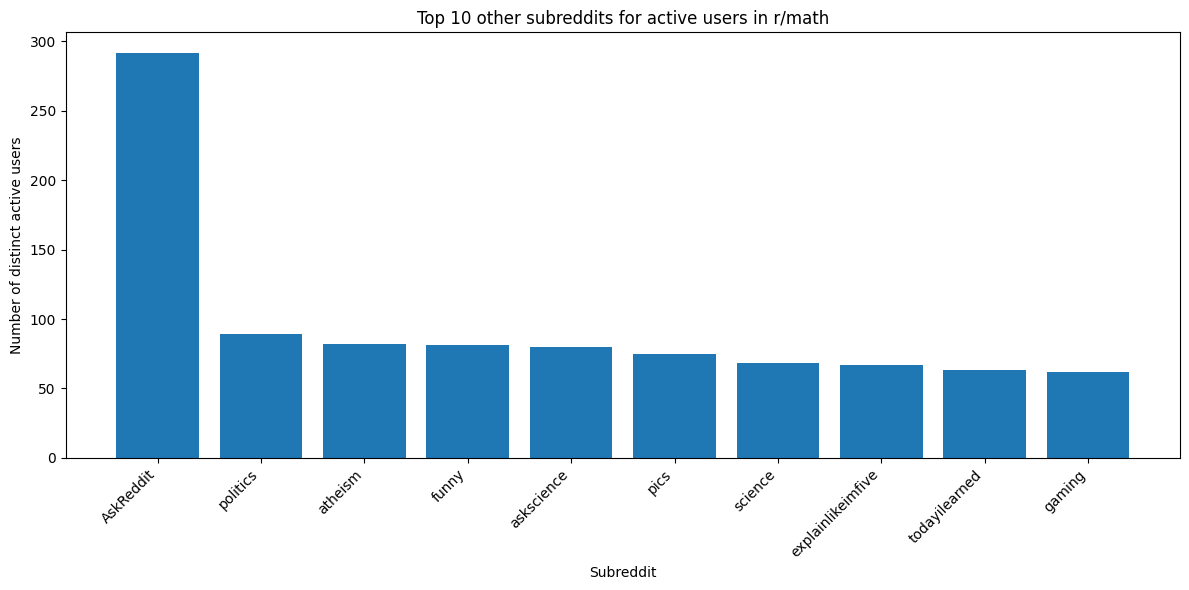

In [14]:
#Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(top10_pd["subreddit"], top10_pd["unique_users"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Subreddit")
plt.ylabel("Number of distinct active users")
plt.title(f"Top 10 other subreddits for active users in r/{target_subreddit}")
plt.tight_layout()
plt.show()

In [15]:
spark.stop()